In [1]:
import pandas as pd
import numpy as np
import joblib

In [3]:
elo_ratings=joblib.load(r'C:\ABHIRAM\projects\FifaWCPredictor\models\elo_ratings.pkl')

In [2]:
data=pd.read_csv(r'C:\ABHIRAM\projects\FifaWCPredictor\data\Processed_result.csv')

In [5]:
data.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,tier,outcome_home,elo_home,elo_away,elo_diff
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,False,4,1.0,1500.0,1500.0,0.0
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,False,4,1.0,1500.0,1495.0,5.0
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False,4,0.5,1500.0,1500.0,0.0
3,2000-01-09,Mexico,Iran,2.0,1.0,Friendly,Oakland,United States,True,4,1.0,1500.0,1500.0,0.0
4,2000-01-09,Ivory Coast,Egypt,2.0,0.0,Friendly,Abidjan,Ivory Coast,False,4,1.0,1500.0,1505.0,-5.0


## Recent form 

In [6]:

from collections import defaultdict

team_history=defaultdict(list)
form_home_list=[]
form_away_list=[]

def get_recent_form(team,n=10):
    history=team_history[team]
    if len(history)==0:
        return 0.5
    recent=history[-n:]
    return sum(recent)/len(recent)



for index,row in data.iterrows():
    team_home=row['home_team']
    team_away=row['away_team']

    form_home=get_recent_form(team_home)
    form_away=get_recent_form(team_away)

    form_home_list.append(form_home)
    form_away_list.append(form_away)

    team_history[team_home].append(row['outcome_home'])
    team_history[team_away].append(1-row['outcome_home'])

data['form_home']=form_home_list
data['form_away']=form_away_list
data['form_diff']=data['form_home']-data['form_away']







In [7]:
data['form_home'].describe()

count    25032.000000
mean         0.507355
std          0.197529
min          0.000000
25%          0.397222
50%          0.500000
75%          0.650000
max          1.000000
Name: form_home, dtype: float64

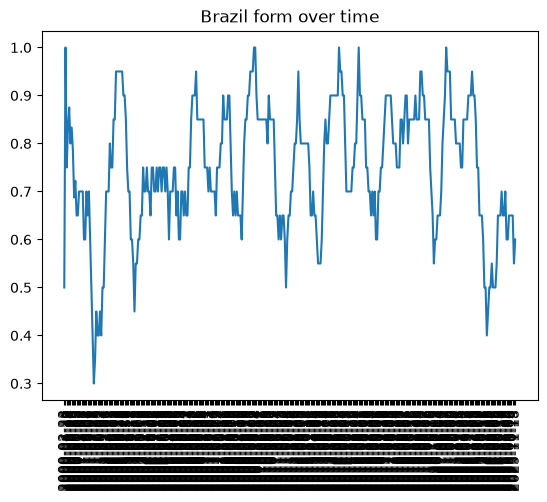

In [8]:
import matplotlib.pyplot as plt

team = "Brazil"
mask = (data['home_team'] == team) | (data['away_team'] == team)
team_data = data[mask].copy()
team_data['team_form'] = team_data.apply(
    lambda r: r['form_home'] if r['home_team'] == team else r['form_away'], axis=1
)

plt.plot(team_data['date'], team_data['team_form'])
plt.xticks(rotation=90)
plt.title(f"{team} form over time")
plt.show()

In [9]:
data.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,tier,outcome_home,elo_home,elo_away,elo_diff,form_home,form_away,form_diff
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,False,4,1.0,1500.0,1500.0,0.0,0.5,0.5,0.0
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,False,4,1.0,1500.0,1495.0,5.0,0.5,0.0,0.5
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False,4,0.5,1500.0,1500.0,0.0,0.5,0.5,0.0
3,2000-01-09,Mexico,Iran,2.0,1.0,Friendly,Oakland,United States,True,4,1.0,1500.0,1500.0,0.0,0.5,0.5,0.0
4,2000-01-09,Ivory Coast,Egypt,2.0,0.0,Friendly,Abidjan,Ivory Coast,False,4,1.0,1500.0,1505.0,-5.0,0.5,1.0,-0.5


## Head to Head

In [10]:
def get_pair_key(team_a,team_b):
    return tuple(sorted([team_a,team_b]))

h2h_history=defaultdict(list)
h2h_home_list=[]


def get_h2h_form(team_home,team_away):
    key=get_pair_key(team_home,team_away)
    history=h2h_history[key]
    if len(history)==0:
        return 0.5
    if team_home==key[0]:
        return sum(history)/len(history)
    else:
        return (len(history)-sum(history))/len(history)
    
for index,row in data.iterrows():
    team_home=row['home_team']
    team_away=row['away_team']
    key=get_pair_key(team_home,team_away)

    h2h_home=get_h2h_form(team_home,team_away)

    h2h_home_list.append(h2h_home)

    if team_home==key[0]:
        h2h_history[key].append(row['outcome_home'])
    else:
        h2h_history[key].append(1-row['outcome_home'])

data['h2h_home']=h2h_home_list


    





In [11]:
data['h2h_home'].describe()

count    25032.000000
mean         0.511726
std          0.287828
min          0.000000
25%          0.375000
50%          0.500000
75%          0.666667
max          1.000000
Name: h2h_home, dtype: float64

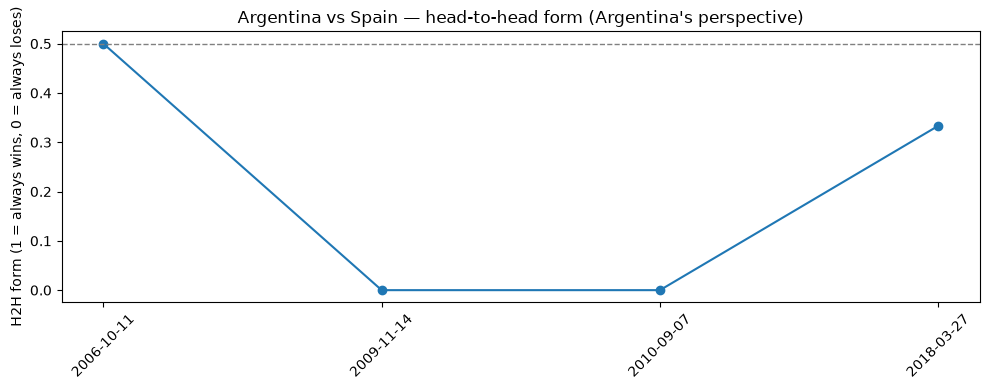

             date  home_team  away_team  outcome_home  h2h_home  team1_h2h
6330   2006-10-11      Spain  Argentina           1.0  0.500000   0.500000
9412   2009-11-14      Spain  Argentina           1.0  1.000000   0.000000
10024  2010-09-07  Argentina      Spain           1.0  0.000000   0.000000
17355  2018-03-27      Spain  Argentina           1.0  0.666667   0.333333


In [12]:
import matplotlib.pyplot as plt

team1 = "Argentina"
team2="Spain"
mask = ((data['home_team']==team1) & (data['away_team']==team2)) | \
       ((data['home_team']==team2) & (data['away_team']==team1))

h2h_data = data[mask][['date','home_team','away_team','outcome_home','h2h_home']]
h2h_data['team1_h2h'] = h2h_data.apply(
    lambda r: r['h2h_home'] if r['home_team'] == team1 else 1-r['h2h_home'], axis=1
)

plt.figure(figsize=(10,4))
plt.plot(h2h_data['date'], h2h_data['team1_h2h'], marker='o')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.title(f"{team1} vs {team2} — head-to-head form ({team1}'s perspective)")
plt.ylabel("H2H form (1 = always wins, 0 = always loses)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(h2h_data)

## Goal Scoring Tendency

In [13]:
goal_scored_history=defaultdict(list)
goal_conceded_history=defaultdict(list)

home_score_list=[]
home_conceded_list=[]

away_score_list=[]
away_conceded_list=[]

league_goals=[]

def get_recent_goal_avg(team,history_dict,n=10):
    history=history_dict[team]
    if len(history) == 0:
        if len(league_goals) == 0:
            return 1.5
        return sum(league_goals) / len(league_goals)
    recent=history[-n:]
    return sum(recent)/len(recent)

for index,row in data.iterrows():
    team_home=row['home_team']
    team_away=row['away_team']

    home_goal_scored=get_recent_goal_avg(team_home,goal_scored_history)
    home_goal_conceded=get_recent_goal_avg(team_home,goal_conceded_history)

    away_goal_scored=get_recent_goal_avg(team_away,goal_scored_history)
    away_goal_conceded=get_recent_goal_avg(team_away,goal_conceded_history)

    home_score_list.append(home_goal_scored)
    home_conceded_list.append(home_goal_conceded)

    away_score_list.append(away_goal_scored)
    away_conceded_list.append(away_goal_conceded)

    goal_scored_history[team_home].append(row['home_score'])
    goal_conceded_history[team_home].append(row['away_score'])

    goal_scored_history[team_away].append(row['away_score'])
    goal_conceded_history[team_away].append(row['home_score'])

    league_goals.append(row['home_score'])
    league_goals.append(row['away_score'])


data['home_avg_goals']=home_score_list
data['home_avg_conceded']=home_conceded_list
data['away_avg_goals']=away_score_list
data['away_avg_conceded']=away_conceded_list

    

In [14]:
data[['home_avg_goals','home_avg_conceded','away_avg_goals','away_avg_conceded']].describe()

,home_avg_goals,home_avg_conceded,away_avg_goals,away_avg_conceded
count,25032.000000,25032.000000,25032.000000,25032.000000
mean,1.400252,1.351791,1.356881,1.404088
std,0.700947,0.833510,0.699896,0.898460
min,0.000000,0.000000,0.000000,0.000000
25%,0.900000,0.900000,0.900000,0.900000
50%,1.300000,1.200000,1.300000,1.200000
75%,1.777778,1.600000,1.700000,1.700000
max,12.000000,19.000000,21.000000,19.500000


In [15]:
print(data['home_score'].max())
print(data['away_score'].max())

31.0
21.0


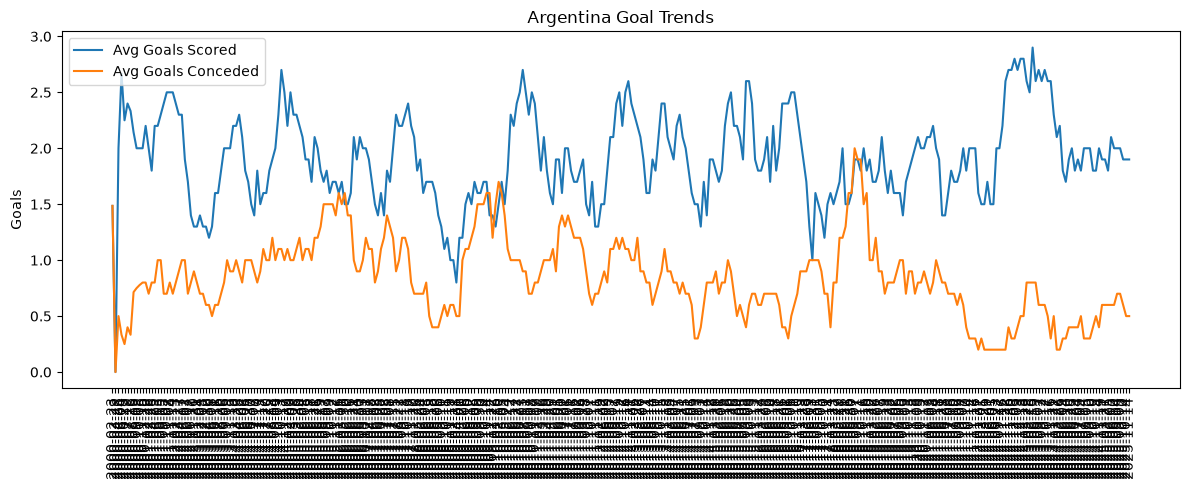

In [16]:
import matplotlib.pyplot as plt

team = "Argentina"

mask = (data['home_team'] == team) | (data['away_team'] == team)
team_data = data[mask].copy()
plt.figure(figsize=(12,5))

team_data['team_avg_goals'] = team_data.apply(
    lambda r: r['home_avg_goals']
    if r['home_team'] == team
    else r['away_avg_goals'],
    axis=1
)
team_data['team_avg_conceded'] = team_data.apply(
    lambda r: r['home_avg_conceded']
    if r['home_team'] == team
    else r['away_avg_conceded'],
    axis=1
)

plt.plot(
    team_data['date'],
    team_data['team_avg_goals'],
    label='Avg Goals Scored'
)

plt.plot(
    team_data['date'],
    team_data['team_avg_conceded'],
    label='Avg Goals Conceded'
)

plt.xticks(rotation=90)
plt.title(f"{team} Goal Trends")
plt.ylabel("Goals")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
data.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'tier', 'outcome_home',
       'elo_home', 'elo_away', 'elo_diff', 'form_home', 'form_away',
       'form_diff', 'h2h_home', 'home_avg_goals', 'home_avg_conceded',
       'away_avg_goals', 'away_avg_conceded'],
      dtype='str')

In [18]:
conditions=[
    data['outcome_home']==1,
    data['outcome_home']==0.5,
    data['outcome_home']==0
]
values=['home_win','draw','away_win']
data['result']=np.select(conditions,values,default='unknown')
y=data['result']

In [19]:
data.to_csv(r'C:\ABHIRAM\projects\FifaWCPredictor\data\processed_result_v2.csv', index=False)

In [20]:
model_state={
    'elo_ratings':elo_ratings,
    'team_history':team_history,
    'h2h_history':h2h_history,
    'goal_scored_history':goal_scored_history,
    'goal_conceded_history':goal_conceded_history,
    'league_goals':league_goals
}

In [23]:
joblib.dump(model_state,r'C:\ABHIRAM\projects\FifaWCPredictor\models\model_state.pkl')

['C:\\ABHIRAM\\projects\\FifaWCPredictor\\models\\model_state.pkl']